# FastDetect benchmark: Llama 3 8B GGUF quantizations

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/papo1011/DetectLlama/blob/main/notebooks/benchmark.ipynb)

This Colab notebook implements the analytic Fast-DetectGPT discrepancy entirely
in Python and benchmarks only the Llama 3 8B **base** GGUF quantizations used by
DetectLlama. `llama-cpp-python` is used only for tokenization and logits.

The experiment:

1. draws separate, balanced calibration (`train`) and evaluation (`test`)
   samples from
   [polsci/ghostbuster-essay-cleaned](https://huggingface.co/datasets/polsci/ghostbuster-essay-cleaned);
2. selects texts with the real Llama 3 tokenizer, from 150 to 5000 tokens;
3. fits a class-balanced threshold per model and context on calibration data only;
4. reports held-out accuracy, balanced accuracy, precision, recall, F1, AUROC,
   and confusion counts;
5. checks whether held-out balanced accuracy changes for longer passages; and
6. compares both re-calibrated and fixed-baseline thresholds as context length
   changes.

**Resource warning.** The catalog contains 11 base-model GGUF files, evaluated
sequentially. FP16 is about 16 GB. Exact analytic scoring of 5000-token essays is
necessarily slower than the old 384-token screening run. Checkpoints are written
after every model, and downloaded files can be deleted immediately after scoring.

Documents may be longer than the active context. The scorer processes them in
overlapping windows, scores every target token exactly once, and combines the
global observed, expected, and variance sums into one document-level score.

Thresholds and accuracy are specific to this dataset, sampling seed, model,
quantization, context policy, and length distribution. They are not universal
AI-detection probabilities.



In [1]:
# Colab setup. CUDA builds can take several minutes.
import os
import subprocess
import sys

# Keep Colab's tested NumPy/Pandas/Matplotlib stack intact. The notebook
# implements its metrics directly and does not need scikit-learn.
base_packages = ["duckdb>=1.1", "huggingface_hub>=0.27"]
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", *base_packages]
)

has_nvidia = subprocess.run(
    ["bash", "-lc", "command -v nvidia-smi >/dev/null && nvidia-smi -L >/dev/null"],
    check=False,
).returncode == 0

llama_env = os.environ.copy()
if has_nvidia:
    llama_env["CMAKE_ARGS"] = "-DGGML_CUDA=on"
    llama_env["FORCE_CMAKE"] = "1"

llama_install = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "--no-cache-dir",
]
if has_nvidia:
    llama_install.extend(["--no-binary", "llama-cpp-python"])
llama_install.append("llama-cpp-python")
subprocess.check_call(llama_install, env=llama_env)
print("Installed llama-cpp-python with", "CUDA" if has_nvidia else "CPU", "support")



Installed llama-cpp-python with CUDA support


This setup deliberately leaves Colab's compiled numerical stack unchanged.
If you previously ran an older version of this notebook that upgraded NumPy,
Pandas, or scikit-learn, choose **Runtime → Restart session**, then run this
notebook again from the top.



In [2]:
import gc
import hashlib
import json
import math
import platform
import shutil
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
from huggingface_hub import HfApi, hf_hub_download
from llama_cpp import Llama
from tqdm.auto import tqdm

try:
    import torch
except ImportError:
    torch = None

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

print("Python:", platform.python_version())
print("CUDA visible:", bool(torch is not None and torch.cuda.is_available()))
if torch is not None and torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Python: 3.12.13
CUDA visible: False


## Configuration

The default run uses 24 calibration texts and 32 held-out evaluation texts,
balanced by class and distributed over four real Llama-token length bands.
Every selected passage has 150–5000 tokens and is scored without the old
384-token truncation.

`MODELS_TO_RUN = "all"` runs all base quantizations plus FP16. For a smoke
test, replace it with IDs such as `["base_q4_0", "base_q5_0"]`.

All models are compared at context 512. To avoid repeating the expensive
5000-token sweep at every context for every quantization, the context-length
experiment is run on `base_q4_0`, configurable below.



In [3]:
SEED = 20260730
DATASET_ID = "polsci/ghostbuster-essay-cleaned"
DATASET_LICENSE = "CC BY 3.0"
CALIBRATION_SPLIT = "train"
EVALUATION_SPLIT = "test"
CALIBRATION_PER_CLASS = 12  # 24 total: 3 per class in each length band
EVALUATION_PER_CLASS = 16   # 32 total: 4 per class in each length band
MIN_TEXT_TOKENS = 150
MAX_TEXT_TOKENS = 5_000
TOKEN_LENGTH_BANDS = [
    ("150–399", 150, 399),
    ("400–699", 400, 699),
    ("700–1024", 700, 1_024),
    ("1025–5000", 1_025, 5_000),
]
CANDIDATES_PER_CHAR_BAND = 500
LONG_BAND_CANDIDATES = 5_000
DELETE_DATASET_AFTER_SAMPLING = True

CONTEXT_LENGTHS = [128, 512, 1024]
BASELINE_CONTEXT = 512
CONTEXT_SWEEP_MODEL_IDS = {"base_q4_0"}
MAX_SCORED_TOKENS = MAX_TEXT_TOKENS
MAX_WINDOW_OVERLAP = 256
LOGIT_BLOCK_ROWS = 16
MOMENT_DTYPE = np.float32

MODELS_TO_RUN = "all"
N_GPU_LAYERS = -1  # all layers; use 0 for CPU or a smaller positive partial offload
N_THREADS = max(1, (os.cpu_count() or 2) - 1)
N_UBATCH = 128
DELETE_MODEL_AFTER_RUN = True
CONTINUE_ON_MODEL_ERROR = True
RESUME_FROM_CHECKPOINTS = True
BOOTSTRAP_REPEATS = 2_000

IN_COLAB = "google.colab" in sys.modules
OUTPUT_DIR = Path("/content/detectllama_results" if IN_COLAB else "detectllama_results")
MODEL_DIR = Path("/content/detectllama_models" if IN_COLAB else "detectllama_models")
DATASET_ROOT = Path(
    "/content/detectllama_dataset" if IN_COLAB else "detectllama_dataset"
)
DATASET_DIR = DATASET_ROOT / DATASET_ID.replace("/", "__")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
DATASET_DIR.mkdir(parents=True, exist_ok=True)

assert CONTEXT_LENGTHS == sorted(set(CONTEXT_LENGTHS))
assert BASELINE_CONTEXT in CONTEXT_LENGTHS
assert min(CONTEXT_LENGTHS) >= 3
assert MIN_TEXT_TOKENS >= 150
assert TOKEN_LENGTH_BANDS[0][1] == MIN_TEXT_TOKENS
assert TOKEN_LENGTH_BANDS[-1][2] == MAX_TEXT_TOKENS
assert all(
    left[2] + 1 == right[1]
    for left, right in zip(TOKEN_LENGTH_BANDS, TOKEN_LENGTH_BANDS[1:])
)

print("Results:", OUTPUT_DIR.resolve())
print("Model staging:", MODEL_DIR.resolve())
print(
    f"| dataset={DATASET_ID} ({DATASET_LICENSE})",
    f"| {2 * (CALIBRATION_PER_CLASS + EVALUATION_PER_CLASS)} texts",
    f"| token range={MIN_TEXT_TOKENS}–{MAX_TEXT_TOKENS}",
    f"| baseline context={BASELINE_CONTEXT}",
    f"| context sweep={sorted(CONTEXT_SWEEP_MODEL_IDS)} @ {CONTEXT_LENGTHS}",
)



Results: /content/detectllama_results
Model staging: /content/detectllama_models
| dataset=polsci/ghostbuster-essay-cleaned (CC BY 3.0) | 56 texts | token range=150–5000 | baseline context=512 | context sweep=['base_q4_0'] @ [128, 512, 1024]


Optional persistent checkpoints in Google Drive:

```python
from google.colab import drive
drive.mount("/content/drive")
OUTPUT_DIR = Path("/content/drive/MyDrive/detectllama_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
```



In [4]:
@dataclass(frozen=True)
class ModelSpec:
    model_id: str
    family: str
    precision: str
    repo_id: str
    filename: str
    size_gb: float

    @property
    def quantized(self):
        return self.precision not in {"FP16", "FP32"}

    @property
    def label(self):
        return f"{self.family} {self.precision}"


BASE_REPO = "QuantFactory/Meta-Llama-3-8B-GGUF"

MODEL_CATALOG = [
    ModelSpec("base_q4_k_s", "Llama 3 8B", "Q4_K_S", BASE_REPO, "Meta-Llama-3-8B.Q4_K_S.gguf", 4.69),
    ModelSpec("base_q4_0", "Llama 3 8B", "Q4_0", BASE_REPO, "Meta-Llama-3-8B.Q4_0.gguf", 4.66),
    ModelSpec("base_q4_k_m", "Llama 3 8B", "Q4_K_M", BASE_REPO, "Meta-Llama-3-8B.Q4_K_M.gguf", 4.92),
    ModelSpec("base_q4_1", "Llama 3 8B", "Q4_1", BASE_REPO, "Meta-Llama-3-8B.Q4_1.gguf", 5.13),
    ModelSpec("base_q5_k_s", "Llama 3 8B", "Q5_K_S", BASE_REPO, "Meta-Llama-3-8B.Q5_K_S.gguf", 5.60),
    ModelSpec("base_q5_0", "Llama 3 8B", "Q5_0", BASE_REPO, "Meta-Llama-3-8B.Q5_0.gguf", 5.60),
    ModelSpec("base_q5_k_m", "Llama 3 8B", "Q5_K_M", BASE_REPO, "Meta-Llama-3-8B.Q5_K_M.gguf", 5.73),
    ModelSpec("base_q5_1", "Llama 3 8B", "Q5_1", BASE_REPO, "Meta-Llama-3-8B.Q5_1.gguf", 6.07),
    ModelSpec("base_q6_k", "Llama 3 8B", "Q6_K", BASE_REPO, "Meta-Llama-3-8B.Q6_K.gguf", 6.60),
    ModelSpec("base_q8_0", "Llama 3 8B", "Q8_0", BASE_REPO, "Meta-Llama-3-8B.Q8_0.gguf", 8.54),
    ModelSpec(
        "base_fp16",
        "Llama 3 8B",
        "FP16",
        "Orneyfish/Meta-Llama-3-8B_F_16.gguf",
        "Meta-Llama-3-8B_F_16.gguf",
        16.07,
    ),
]

catalog_df = pd.DataFrame(
    [
        {
            **asdict(model),
            "quantized": model.quantized,
            "label": model.label,
        }
        for model in MODEL_CATALOG
    ]
)
display(catalog_df)
print(f"{len(MODEL_CATALOG)} models; sequential download volume ≈ {catalog_df.size_gb.sum():.1f} GB")



,model_id,family,precision,repo_id,filename,size_gb,quantized,label
0,base_q4_k_s,Llama 3 8B,Q4_K_S,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_K_S.gguf,4.69,True,Llama 3 8B Q4_K_S
1,base_q4_0,Llama 3 8B,Q4_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_0.gguf,4.66,True,Llama 3 8B Q4_0
2,base_q4_k_m,Llama 3 8B,Q4_K_M,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_K_M.gguf,4.92,True,Llama 3 8B Q4_K_M
3,base_q4_1,Llama 3 8B,Q4_1,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_1.gguf,5.13,True,Llama 3 8B Q4_1
4,base_q5_k_s,Llama 3 8B,Q5_K_S,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_K_S.gguf,5.60,True,Llama 3 8B Q5_K_S
5,base_q5_0,Llama 3 8B,Q5_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_0.gguf,5.60,True,Llama 3 8B Q5_0
6,base_q5_k_m,Llama 3 8B,Q5_K_M,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_K_M.gguf,5.73,True,Llama 3 8B Q5_K_M
7,base_q5_1,Llama 3 8B,Q5_1,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_1.gguf,6.07,True,Llama 3 8B Q5_1
8,base_q6_k,Llama 3 8B,Q6_K,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q6_K.gguf,6.60,True,Llama 3 8B Q6_K
9,base_q8_0,Llama 3 8B,Q8_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q8_0.gguf,8.54,True,Llama 3 8B Q8_0


11 models; sequential download volume ≈ 73.6 GB


In [5]:
if MODELS_TO_RUN == "all":
    selected_models = MODEL_CATALOG
else:
    wanted = set(MODELS_TO_RUN)
    known = {model.model_id for model in MODEL_CATALOG}
    unknown = wanted - known
    if unknown:
        raise ValueError(f"Unknown model IDs: {sorted(unknown)}")
    selected_models = [model for model in MODEL_CATALOG if model.model_id in wanted]

selected_model_ids = {model.model_id for model in selected_models}
context_sweep_model_ids = CONTEXT_SWEEP_MODEL_IDS & selected_model_ids
if not context_sweep_model_ids:
    context_sweep_model_ids = {selected_models[0].model_id}
    print("Context sweep fallback:", sorted(context_sweep_model_ids))

display(catalog_df[catalog_df.model_id.isin([m.model_id for m in selected_models])])



,model_id,family,precision,repo_id,filename,size_gb,quantized,label
0,base_q4_k_s,Llama 3 8B,Q4_K_S,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_K_S.gguf,4.69,True,Llama 3 8B Q4_K_S
1,base_q4_0,Llama 3 8B,Q4_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_0.gguf,4.66,True,Llama 3 8B Q4_0
2,base_q4_k_m,Llama 3 8B,Q4_K_M,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_K_M.gguf,4.92,True,Llama 3 8B Q4_K_M
3,base_q4_1,Llama 3 8B,Q4_1,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q4_1.gguf,5.13,True,Llama 3 8B Q4_1
4,base_q5_k_s,Llama 3 8B,Q5_K_S,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_K_S.gguf,5.60,True,Llama 3 8B Q5_K_S
5,base_q5_0,Llama 3 8B,Q5_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_0.gguf,5.60,True,Llama 3 8B Q5_0
6,base_q5_k_m,Llama 3 8B,Q5_K_M,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_K_M.gguf,5.73,True,Llama 3 8B Q5_K_M
7,base_q5_1,Llama 3 8B,Q5_1,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q5_1.gguf,6.07,True,Llama 3 8B Q5_1
8,base_q6_k,Llama 3 8B,Q6_K,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q6_K.gguf,6.60,True,Llama 3 8B Q6_K
9,base_q8_0,Llama 3 8B,Q8_0,QuantFactory/Meta-Llama-3-8B-GGUF,Meta-Llama-3-8B.Q8_0.gguf,8.54,True,Llama 3 8B Q8_0


## Dataset sampling

Ghostbuster label `6` is human; labels `0–5` are outputs from Claude/GPT
generation strategies and are mapped to AI label `1`. Calibration comes only
from the dataset's training split; final metrics come only from its test split.
The pinned Parquet files are downloaded through Hugging Face and
queried with DuckDB, avoiding the `datasets`/PyArrow import stack. Candidate
rows are deduplicated by normalized-text hash. A vocabulary-only Llama 3 GGUF
load supplies the exact tokenizer, so the 150–5000-token limits and length
strata do not rely on character-count approximations.



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Pinned dataset revision: 953b44b7b1d8278a5c955ba0649846900cab4285
Using separate splits: train for calibration; test for evaluation
Loaded cached samples: /content/detectllama_results/samples_polsci__ghostbuster-essay-cleaned_953b44b7_seed20260730_tok150-5000_bands150-399_400-699_700-1024_1025-5000_cal12x2_eval16x2.csv


n  min_tokens  median_tokens  max_tokens
partition   label length_band                                          
calibration 0     1025–5000    3        1057         1137.0        1821
                  150–399      3         334          371.0         390
                  400–699      3         451          476.0         534
                  700–1024     3         753          816.0         836
            1     1025–5000    3        1028         1058.0        1112
                  150–399      3         371          381.0         392
                  400–699      3         530          575.0         641
                  700–1024     3         825          833.0         925
evaluation  0     1025–5000    4        1198         1342.0        3355
                  150–399      4         207          339.0         391
                  400–699      4         427          543.0         698
                  700–1024     4         756          898.5         949
            1     1025–5000    4        1052         1085.0        1111
                  150–399      4         308          339.5         399
                  400–699      4         476          552.0         656
                  700–1024     4         729          835.5         982

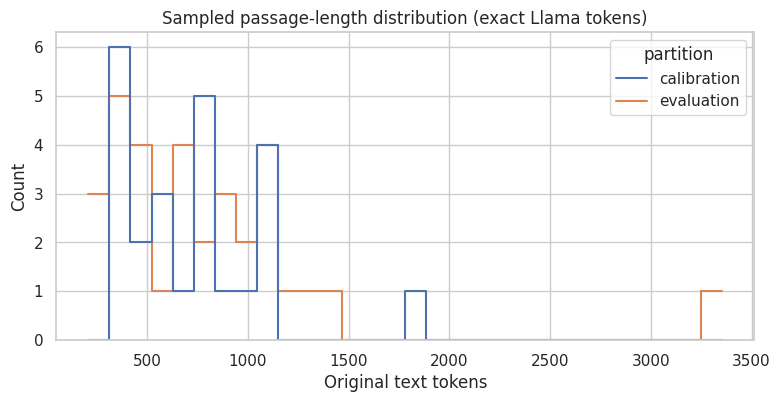

In [6]:
dataset_info = HfApi().dataset_info(DATASET_ID)
DATASET_REVISION = dataset_info.sha
print("Pinned dataset revision:", DATASET_REVISION)
print("Using separate splits:", CALIBRATION_SPLIT, "for calibration;", EVALUATION_SPLIT, "for evaluation")

DATASET_FILES = {
    "train": ["data/train-00000-of-00001.parquet"],
    "test": ["data/test-00000-of-00001.parquet"],
}
downloaded_dataset_files = set()


def normalized_text_hash(text):
    normalized = " ".join(str(text).split()).casefold()
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()


def local_parquet_files(split):
    if split not in DATASET_FILES:
        raise ValueError(f"Unknown dataset split: {split}")
    paths = []
    for filename in DATASET_FILES[split]:
        target = DATASET_DIR / filename
        existed_before = target.exists()
        path = Path(
            hf_hub_download(
                repo_id=DATASET_ID,
                repo_type="dataset",
                filename=filename,
                revision=DATASET_REVISION,
                local_dir=DATASET_DIR,
            )
        )
        paths.append(str(path))
        if not existed_before:
            downloaded_dataset_files.add(path)
    return paths


def collect_candidates(split, seed):
    paths = local_parquet_files(split)
    seen_hashes = set()
    rows = []
    connection = duckdb.connect()
    try:
        connection.read_parquet(paths).create_view("split_rows")
        for label in (0, 1):
            for band_index, (_, token_low, token_high) in enumerate(TOKEN_LENGTH_BANDS):
                # Broad character filters reduce I/O only; exact acceptance uses
                # the Llama tokenizer below. The wide 2–8 char/token envelope
                # deliberately tolerates code, punctuation, and non-English text.
                char_low = max(200, token_low * 2)
                char_high = token_high * 8
                target_chars = 4 * ((token_low + token_high) // 2)
                candidate_limit = (
                    LONG_BAND_CANDIDATES
                    if band_index == len(TOKEN_LENGTH_BANDS) - 1
                    else CANDIDATES_PER_CHAR_BAND
                )
                candidate_rows = connection.execute(
                    """
                    SELECT text, label
                    FROM (
                        SELECT DISTINCT
                            trim(CAST(text AS VARCHAR)) AS text,
                            CASE
                                WHEN CAST(label AS INTEGER) = 6 THEN 0
                                ELSE 1
                            END AS label
                        FROM split_rows
                        WHERE (
                            CASE
                                WHEN CAST(label AS INTEGER) = 6 THEN 0
                                ELSE 1
                            END
                        ) = ?
                          AND length(trim(CAST(text AS VARCHAR))) BETWEEN ? AND ?
                    )
                    ORDER BY abs(length(text) - ?), hash(text || ?)
                    LIMIT ?
                    """,
                    [
                        label,
                        char_low,
                        char_high,
                        target_chars,
                        f":seed={seed}:label={label}:band={band_index}",
                        candidate_limit,
                    ],
                ).fetchall()

                for source_index, (candidate_text, candidate_label) in enumerate(candidate_rows):
                    if int(candidate_label) != label:
                        raise RuntimeError("DuckDB returned an unexpected label")
                    text = str(candidate_text).strip()
                    text_hash = normalized_text_hash(text)
                    if text_hash in seen_hashes:
                        continue
                    seen_hashes.add(text_hash)
                    rows.append(
                        {
                            "sample_id": (
                                f"{split}:{label}:{band_index}:{source_index}:"
                                f"{text_hash[:12]}"
                            ),
                            "text": text,
                            "label": label,
                            "text_hash": text_hash,
                            "char_count": len(text),
                        }
                    )
    finally:
        connection.close()

    if not rows:
        raise RuntimeError(f"No candidates collected from split {split}")
    return pd.DataFrame(rows).drop_duplicates("text_hash")


def token_length_band(token_count):
    for band_label, low, high in TOKEN_LENGTH_BANDS:
        if low <= token_count <= high:
            return band_label
    return None


def add_exact_token_counts(candidates, tokenizer):
    frame = candidates.copy()
    frame["original_token_count"] = [
        len(
            tokenizer.tokenize(
                str(text).encode("utf-8"),
                add_bos=True,
                special=False,
            )
        ) - 1
        for text in tqdm(frame.text, desc="Exact Llama token counts")
    ]
    frame["length_band"] = frame.original_token_count.map(token_length_band)
    return frame.dropna(subset=["length_band"]).copy()


def per_band_quotas(per_class):
    base, remainder = divmod(per_class, len(TOKEN_LENGTH_BANDS))
    return {
        band_label: base + int(position < remainder)
        for position, (band_label, _, _) in enumerate(TOKEN_LENGTH_BANDS)
    }


def balanced_band_quotas(frame, per_class):
    requested = per_band_quotas(per_class)
    availability = (
        frame.groupby(["length_band", "label"])
        .size()
        .unstack(fill_value=0)
        .reindex([band for band, _, _ in TOKEN_LENGTH_BANDS], fill_value=0)
        .reindex(columns=[0, 1], fill_value=0)
    )
    # A band can contain only as many balanced pairs as its rarer class.
    capacity = availability.min(axis=1).astype(int).to_dict()
    allocated = {
        band: min(quota, capacity[band])
        for band, quota in requested.items()
    }
    deficit = per_class - sum(allocated.values())

    # Move missing pairs to other bands, one pass at a time, so no single
    # well-populated band absorbs the entire deficit.
    while deficit:
        changed = False
        for band in requested:
            if allocated[band] < capacity[band]:
                allocated[band] += 1
                deficit -= 1
                changed = True
                if deficit == 0:
                    break
        if not changed:
            table = availability.rename(columns={0: "human", 1: "AI"})
            raise RuntimeError(
                f"Need {per_class} balanced examples per class, but the common "
                f"per-band capacity is only {sum(capacity.values())}.\n{table}"
            )

    adjustments = []
    for band in requested:
        if allocated[band] != requested[band]:
            adjustments.append(
                {
                    "length_band": band,
                    "human_available": int(availability.loc[band, 0]),
                    "ai_available": int(availability.loc[band, 1]),
                    "requested_per_class": requested[band],
                    "selected_per_class": allocated[band],
                    "quota_change": allocated[band] - requested[band],
                }
            )
    return allocated, pd.DataFrame(adjustments)


def sample_across_lengths(candidates, per_class, seed, excluded_hashes=frozenset()):
    frame = (
        candidates[~candidates.text_hash.isin(excluded_hashes)]
        .drop_duplicates("text_hash")
        .copy()
    )
    rng = np.random.default_rng(seed)
    quotas, quota_relaxations = balanced_band_quotas(frame, per_class)
    chosen_indices = []

    for label in (0, 1):
        for band_label, quota in quotas.items():
            group = frame[
                (frame.label == label) & (frame.length_band == band_label)
            ]
            chosen_indices.extend(
                rng.choice(
                    group.index.to_numpy(),
                    size=quota,
                    replace=False,
                ).tolist()
            )

    result = frame.loc[chosen_indices].sample(frac=1, random_state=seed).reset_index(drop=True)
    assert result.label.value_counts().sort_index().to_dict() == {0: per_class, 1: per_class}
    per_band_counts = result.groupby(["length_band", "label"]).size().unstack(fill_value=0)
    assert (per_band_counts[0] == per_band_counts[1]).all()
    result.attrs["quota_relaxations"] = quota_relaxations
    return result


band_signature = "_".join(
    f"{low}-{high}" for _, low, high in TOKEN_LENGTH_BANDS
)
dataset_cache_name = DATASET_ID.replace("/", "__")
sample_cache = OUTPUT_DIR / (
    f"samples_{dataset_cache_name}_{DATASET_REVISION[:8]}_seed{SEED}_"
    f"tok{MIN_TEXT_TOKENS}-{MAX_TEXT_TOKENS}_bands{band_signature}_"
    f"cal{CALIBRATION_PER_CLASS}x2_eval{EVALUATION_PER_CLASS}x2.csv"
)
sampling_staged_model_paths = set()
if sample_cache.exists() and RESUME_FROM_CHECKPOINTS:
    samples = pd.read_csv(sample_cache)
    required_sample_columns = {
        "sample_id", "partition", "label", "text", "text_hash",
        "char_count", "original_token_count", "length_band",
    }
    if not required_sample_columns.issubset(samples.columns):
        raise RuntimeError(f"Stale sample cache: {sample_cache}")
    calibration_df = samples[samples.partition == "calibration"].copy()
    evaluation_df = samples[samples.partition == "evaluation"].copy()
    print("Loaded cached samples:", sample_cache)
else:
    calibration_candidates = collect_candidates(CALIBRATION_SPLIT, SEED)
    evaluation_candidates = collect_candidates(EVALUATION_SPLIT, SEED + 1)

    tokenizer_model = selected_models[0]
    tokenizer_target = MODEL_DIR / tokenizer_model.filename
    tokenizer_existed_before = tokenizer_target.exists()
    print("Loading exact tokenizer from:", tokenizer_model.label)
    tokenizer_path = Path(
        hf_hub_download(
            repo_id=tokenizer_model.repo_id,
            filename=tokenizer_model.filename,
            local_dir=MODEL_DIR,
        )
    )
    if not tokenizer_existed_before:
        sampling_staged_model_paths.add(tokenizer_path)
    sampling_tokenizer = Llama(
        model_path=str(tokenizer_path),
        vocab_only=True,
        n_ctx=16,
        n_gpu_layers=0,
        use_mmap=True,
        verbose=False,
    )
    try:
        calibration_candidates = add_exact_token_counts(
            calibration_candidates,
            sampling_tokenizer,
        )
        evaluation_candidates = add_exact_token_counts(
            evaluation_candidates,
            sampling_tokenizer,
        )
    finally:
        sampling_tokenizer.close()
        del sampling_tokenizer
        gc.collect()

    candidate_availability = pd.concat(
        [
            calibration_candidates.assign(partition="calibration"),
            evaluation_candidates.assign(partition="evaluation"),
        ],
        ignore_index=True,
    )
    display(
        candidate_availability.groupby(["partition", "label", "length_band"])
        .size()
        .rename("available")
        .reset_index()
    )

    calibration_df = sample_across_lengths(
        calibration_candidates,
        CALIBRATION_PER_CLASS,
        SEED,
    )
    calibration_quota_relaxations = calibration_df.attrs[
        "quota_relaxations"
    ].assign(partition="calibration")
    evaluation_df = sample_across_lengths(
        evaluation_candidates,
        EVALUATION_PER_CLASS,
        SEED + 1,
        excluded_hashes=set(calibration_df.text_hash),
    )
    evaluation_quota_relaxations = evaluation_df.attrs[
        "quota_relaxations"
    ].assign(partition="evaluation")
    sampling_relaxations = pd.concat(
        [calibration_quota_relaxations, evaluation_quota_relaxations],
        ignore_index=True,
    )
    if not sampling_relaxations.empty:
        warnings.warn(
            "Some per-band quotas were reallocated as balanced human/AI pairs. "
            "Overall and within-band class balance are unchanged."
        )
        display(sampling_relaxations)

    # Pandas compares attrs while concatenating. Keeping a DataFrame inside
    # attrs makes that comparison ambiguous, so diagnostics are detached first.
    calibration_df.attrs.clear()
    evaluation_df.attrs.clear()
    calibration_df["partition"] = "calibration"
    evaluation_df["partition"] = "evaluation"
    samples = pd.concat([calibration_df, evaluation_df], ignore_index=True)
    samples.to_csv(sample_cache, index=False)
    print("Saved samples:", sample_cache)
    if DELETE_DATASET_AFTER_SAMPLING:
        for path in sorted(downloaded_dataset_files):
            if path.exists():
                path.unlink()
        print(f"Deleted {len(downloaded_dataset_files)} staged Parquet file(s)")

assert set(calibration_df.label.unique()) == {0, 1}
assert set(evaluation_df.label.unique()) == {0, 1}
assert set(calibration_df.text_hash).isdisjoint(evaluation_df.text_hash)
assert len(calibration_df) == 2 * CALIBRATION_PER_CLASS
assert len(evaluation_df) == 2 * EVALUATION_PER_CLASS
assert samples.original_token_count.between(MIN_TEXT_TOKENS, MAX_TEXT_TOKENS).all()

display(
    samples.groupby(["partition", "label", "length_band"])
    .agg(
        n=("sample_id", "size"),
        min_tokens=("original_token_count", "min"),
        median_tokens=("original_token_count", "median"),
        max_tokens=("original_token_count", "max"),
    )
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(
    data=samples,
    x="original_token_count",
    hue="partition",
    bins=30,
    element="step",
    fill=False,
    ax=ax,
)
ax.set_title("Sampled passage-length distribution (exact Llama tokens)")
ax.set_xlabel("Original text tokens")
plt.show()



## Full analytic FastDetect implementation

For each observed next token \(x_t\), with model probabilities \(p(v)\), the
code accumulates:

\[
\log p(x_t), \quad
\mu_t = \sum_v p(v)\log p(v), \quad
\sigma_t^2 = \sum_v p(v)\log^2p(v)-\mu_t^2.
\]

The passage discrepancy is:

\[
d(x)=\frac{\sum_t \log p(x_t)-\sum_t\mu_t}
{\sqrt{\sum_t\sigma_t^2}}.
\]

Positive scores are more model-like. Passages are scored exactly up to the
configured 5000-token application limit, even when the selected context is
shorter than the document. Each
target token is scored exactly once; later windows retain preceding context
and the final statistic is reconstructed from global sums, rather than by
averaging per-window scores.



In [7]:
def accumulate_token_moments(logits, labels, block_rows=LOGIT_BLOCK_ROWS):
    """Return sums of observed log-p, expected log-p, and variance."""
    labels = np.asarray(labels, dtype=np.int64)
    if logits.shape[0] != labels.shape[0]:
        raise ValueError("Logit and label row counts differ")

    observed_sum = 0.0
    expected_sum = 0.0
    variance_sum = 0.0

    for start in range(0, len(labels), block_rows):
        stop = min(len(labels), start + block_rows)
        block = np.asarray(logits[start:stop], dtype=MOMENT_DTYPE)
        if not np.isfinite(block).all():
            raise FloatingPointError("Non-finite logits")

        row_max = block.max(axis=1, keepdims=True)
        if not np.isfinite(row_max).all():
            raise FloatingPointError("Non-finite maximum logit")
        shifted = block - row_max
        exp_shifted = np.exp(shifted)
        normalizer = exp_shifted.sum(axis=1, dtype=np.float64)
        log_normalizer = np.log(normalizer)
        local_labels = labels[start:stop]
        observed = (
            shifted[np.arange(stop - start), local_labels].astype(np.float64)
            - log_normalizer
        )

        # Since log p(v) = shifted(v) - log(Z), its variance equals the
        # variance of shifted logits. This avoids materializing probability
        # and log-probability matrices over the full 128k vocabulary.
        mean_shifted = (
            (exp_shifted * shifted).sum(axis=1, dtype=np.float64) / normalizer
        )
        mean_shifted_square = (
            (exp_shifted * shifted * shifted).sum(axis=1, dtype=np.float64)
            / normalizer
        )
        expected = mean_shifted - log_normalizer
        variance = np.maximum(
            0.0,
            mean_shifted_square - mean_shifted * mean_shifted,
        )

        observed_sum += observed.sum(dtype=np.float64)
        expected_sum += expected.sum(dtype=np.float64)
        variance_sum += variance.sum(dtype=np.float64)

    return observed_sum, expected_sum, variance_sum


class FastDetectScorer:
    def __init__(
        self,
        llm,
        max_overlap=MAX_WINDOW_OVERLAP,
        max_scored_tokens=MAX_SCORED_TOKENS,
    ):
        self.llm = llm
        self.max_overlap = max_overlap
        self.max_scored_tokens = max_scored_tokens

    def tokenize(self, text):
        return self.llm.tokenize(
            str(text).encode("utf-8"),
            add_bos=True,
            special=False,
        )

    def limit_tokens(self, tokens):
        if self.max_scored_tokens is None:
            return tokens
        return tokens[: self.max_scored_tokens + 1]

    def score_tokens(self, tokens, context_length):
        started = time.perf_counter()
        if len(tokens) < 2:
            raise ValueError("At least one text token is required")
        if context_length < 3 or context_length > self.llm.n_ctx():
            raise ValueError(
                f"context_length must be in [3, {self.llm.n_ctx()}], got {context_length}"
            )

        bos_token = self.llm.token_bos()
        has_bos = bos_token >= 0 and tokens[0] == bos_token
        content_floor = 1 if has_bos else 0
        overlap = min(
            self.max_overlap,
            max(1, (context_length - 1) // 4),
            context_length - 2,
        )

        observed_sum = 0.0
        expected_sum = 0.0
        variance_sum = 0.0
        target_start = 1
        windows = 0
        scored_token_total = 0

        while target_start < len(tokens):
            first_window = target_start == 1
            prefix_tokens = 0 if first_window or not has_bos else 1
            context_start = (
                0
                if first_window
                else max(content_floor, target_start - overlap)
            )
            content_capacity = context_length - prefix_tokens
            window_end = min(len(tokens), context_start + content_capacity)
            scored_tokens = window_end - target_start
            if scored_tokens <= 0:
                raise RuntimeError("Windowed scorer could not advance")

            window_tokens = []
            if prefix_tokens:
                window_tokens.append(bos_token)
            window_tokens.extend(tokens[context_start:window_end])
            if len(window_tokens) > context_length:
                raise RuntimeError("A scoring window exceeds context_length")

            local_target_start = (
                1
                if first_window
                else prefix_tokens + target_start - context_start
            )
            first_predictor = local_target_start - 1

            self.llm.reset()
            self.llm.eval(window_tokens)
            logits = self.llm.scores[
                first_predictor : first_predictor + scored_tokens
            ]
            labels = tokens[target_start:window_end]
            observed, expected, variance = accumulate_token_moments(logits, labels)
            observed_sum += observed
            expected_sum += expected
            variance_sum += variance

            target_start = window_end
            windows += 1
            scored_token_total += scored_tokens

        if scored_token_total != len(tokens) - 1:
            raise RuntimeError(
                f"Incomplete token coverage: scored {scored_token_total} of "
                f"{len(tokens) - 1} target tokens"
            )
        if len(tokens) > context_length and windows < 2:
            raise RuntimeError("Longer-than-context text was not windowed")
        if not np.isfinite(variance_sum) or variance_sum <= 1e-9:
            raise FloatingPointError("Discrepancy variance is zero or non-finite")
        score = (observed_sum - expected_sum) / math.sqrt(variance_sum)
        if not np.isfinite(score):
            raise FloatingPointError("Discrepancy is non-finite")

        return {
            "score": float(score),
            "token_count": len(tokens) - 1,
            "scored_token_count": scored_token_total,
            "complete_coverage": True,
            "windows": windows,
            "context_overlap": overlap if windows > 1 else 0,
            "elapsed_seconds": time.perf_counter() - started,
        }

    def score_text(self, text, context_length):
        return self.score_tokens(
            self.limit_tokens(self.tokenize(text)),
            context_length,
        )


# A numerical unit test independent of any model.
toy_logits = np.array([[0.1, 1.2, -0.4], [2.0, 0.0, -1.0]], dtype=np.float32)
toy_labels = np.array([1, 0])
toy_sums = accumulate_token_moments(toy_logits, toy_labels, block_rows=1)
toy_log_probability = toy_logits.astype(np.float64)
toy_log_probability -= toy_log_probability.max(axis=1, keepdims=True)
toy_log_probability -= np.log(
    np.exp(toy_log_probability).sum(axis=1, keepdims=True)
)
toy_probability = np.exp(toy_log_probability)
toy_reference = (
    toy_log_probability[np.arange(2), toy_labels].sum(),
    (toy_probability * toy_log_probability).sum(),
    (
        (toy_probability * toy_log_probability**2).sum(axis=1)
        - (toy_probability * toy_log_probability).sum(axis=1) ** 2
    ).sum(),
)
assert np.allclose(toy_sums, toy_reference, rtol=1e-5, atol=1e-6)
print("Analytic moment test passed:", toy_sums)



Analytic moment test passed: (np.float64(-0.5982249649734991), np.float64(-1.4016989490817617), np.float64(1.106806087587156))


## Benchmark runner

A model is loaded once and every passage is tokenized once. All models run the
baseline context; only the configured representative model runs the complete
context sweep. Per-model CSV
checkpoints make the sweep resumable.



In [8]:
sample_columns = [
    "sample_id",
    "partition",
    "label",
    "text",
    "text_hash",
    "char_count",
    "original_token_count",
    "length_band",
]
benchmark_samples = samples[sample_columns].copy()


def contexts_for_model(model):
    if model.model_id in context_sweep_model_ids:
        return CONTEXT_LENGTHS
    return [BASELINE_CONTEXT]


def model_checkpoint_path(model):
    model_contexts = contexts_for_model(model)
    profile = (
        f"{dataset_cache_name}_{DATASET_REVISION[:8]}_"
        f"n{len(benchmark_samples)}_t{MAX_SCORED_TOKENS}_"
        f"c{'-'.join(map(str, model_contexts))}"
    )
    return OUTPUT_DIR / f"scores_{model.model_id}_{profile}.csv"


def valid_checkpoint(frame, model):
    required = {
        "model_id",
        "sample_id",
        "partition",
        "label",
        "context_length",
        "score",
        "token_count",
        "original_token_count",
        "scored_token_count",
        "complete_coverage",
        "windows",
        "length_band",
    }
    if not required.issubset(frame.columns):
        return False
    if set(frame.model_id.unique()) != {model.model_id}:
        return False
    model_contexts = contexts_for_model(model)
    if set(frame.context_length.unique()) != set(model_contexts):
        return False
    expected_pairs = {
        (sample_id, context_length)
        for sample_id in benchmark_samples.sample_id
        for context_length in model_contexts
    }
    observed_pairs = set(zip(frame.sample_id, frame.context_length))
    return len(frame) == len(expected_pairs) and observed_pairs == expected_pairs


def score_one_model(model):
    model_started = time.perf_counter()
    model_contexts = contexts_for_model(model)
    checkpoint = model_checkpoint_path(model)
    if checkpoint.exists() and RESUME_FROM_CHECKPOINTS:
        cached = pd.read_csv(checkpoint)
        if valid_checkpoint(cached, model):
            print("Using checkpoint:", checkpoint.name)
            return cached
        print("Ignoring stale checkpoint:", checkpoint.name)

    free_gb = shutil.disk_usage(MODEL_DIR).free / 1e9
    if free_gb < model.size_gb + 1.0:
        raise RuntimeError(
            f"{model.label} needs about {model.size_gb:.1f} GB plus headroom; "
            f"only {free_gb:.1f} GB is free."
        )

    staged_target = MODEL_DIR / model.filename
    existed_before = staged_target.exists()
    print(f"Downloading/loading {model.label} ({model.size_gb:.2f} GB)")
    model_path = Path(
        hf_hub_download(
            repo_id=model.repo_id,
            filename=model.filename,
            local_dir=MODEL_DIR,
        )
    )

    effective_gpu_layers = (
        N_GPU_LAYERS
        if torch is not None and torch.cuda.is_available()
        else 0
    )
    llm = None
    scorer = None
    try:
        llm = Llama(
            model_path=str(model_path),
            n_ctx=max(model_contexts),
            n_batch=max(model_contexts),
            n_ubatch=min(N_UBATCH, max(model_contexts)),
            n_threads=N_THREADS,
            n_gpu_layers=effective_gpu_layers,
            logits_all=True,
            embedding=False,
            use_mmap=True,
            verbose=False,
        )
        scorer = FastDetectScorer(llm)
        rows = []
        iterator = tqdm(
            benchmark_samples.itertuples(index=False),
            total=len(benchmark_samples),
            desc=model.model_id,
        )
        for sample in iterator:
            base_record = {
                "model_id": model.model_id,
                "family": model.family,
                "precision": model.precision,
                "quantized": model.quantized,
                "model_label": model.label,
                "sample_id": sample.sample_id,
                "partition": sample.partition,
                "label": sample.label,
                "char_count": sample.char_count,
                "length_band": sample.length_band,
            }
            try:
                full_tokens = scorer.tokenize(sample.text)
                original_token_count = len(full_tokens) - 1
                if original_token_count != int(sample.original_token_count):
                    raise RuntimeError(
                        "Tokenizer mismatch with cached sampling token count: "
                        f"{original_token_count} != {sample.original_token_count}"
                    )
                tokens = scorer.limit_tokens(full_tokens)
                base_record["original_token_count"] = original_token_count
                base_record["truncated_for_speed"] = len(tokens) < len(full_tokens)
            except Exception as exc:
                for context_length in model_contexts:
                    rows.append(
                        {
                            **base_record,
                            "context_length": context_length,
                            "score": np.nan,
                            "token_count": np.nan,
                            "scored_token_count": np.nan,
                            "complete_coverage": False,
                            "windows": np.nan,
                            "context_overlap": np.nan,
                            "elapsed_seconds": np.nan,
                            "error": f"tokenization: {exc!r}",
                        }
                    )
                continue

            for context_length in model_contexts:
                try:
                    result = scorer.score_tokens(tokens, context_length)
                    rows.append(
                        {
                            **base_record,
                            "context_length": context_length,
                            **result,
                            "error": "",
                        }
                    )
                except Exception as exc:
                    rows.append(
                        {
                            **base_record,
                            "context_length": context_length,
                            "score": np.nan,
                            "token_count": len(tokens) - 1,
                            "scored_token_count": np.nan,
                            "complete_coverage": False,
                            "windows": np.nan,
                            "context_overlap": np.nan,
                            "elapsed_seconds": np.nan,
                            "error": repr(exc),
                        }
                    )

        frame = pd.DataFrame(rows)
        temporary = checkpoint.with_suffix(".tmp.csv")
        frame.to_csv(temporary, index=False)
        temporary.replace(checkpoint)
        print("Saved:", checkpoint)
        print(f"{model.label}: {(time.perf_counter() - model_started) / 60:.1f} min")
        return frame
    finally:
        scorer = None
        if llm is not None:
            llm.close()
            del llm
        gc.collect()
        if torch is not None and torch.cuda.is_available():
            torch.cuda.empty_cache()
        staged_for_sampling = model_path in sampling_staged_model_paths
        if (
            DELETE_MODEL_AFTER_RUN
            and (not existed_before or staged_for_sampling)
            and model_path.exists()
        ):
            model_path.unlink()
            sampling_staged_model_paths.discard(model_path)
            print("Deleted staged model file:", model_path.name)


score_frames = []
model_failures = []
for model in selected_models:
    try:
        score_frames.append(score_one_model(model))
    except Exception as exc:
        model_failures.append(
            {
                **asdict(model),
                "error": repr(exc),
            }
        )
        print(f"FAILED: {model.label}: {exc}")
        if not CONTINUE_ON_MODEL_ERROR:
            raise

if not score_frames:
    raise RuntimeError("No model completed. Inspect the model_failures table.")

scores = pd.concat(score_frames, ignore_index=True)
failures_df = pd.DataFrame(model_failures)
successful_scores = scores.dropna(subset=["score"]).copy()
coverage_flags = (
    successful_scores.complete_coverage.astype(str).str.lower().eq("true")
)
if not coverage_flags.all():
    raise RuntimeError("At least one successful score has incomplete token coverage")
if not np.array_equal(
    successful_scores.scored_token_count.to_numpy(dtype=int),
    successful_scores.token_count.to_numpy(dtype=int),
):
    raise RuntimeError("Scored-token counts do not match document-token counts")
longer_than_context = successful_scores[
    successful_scores.original_token_count >= successful_scores.context_length
]
if not longer_than_context.empty and not (longer_than_context.windows >= 2).all():
    raise RuntimeError("A longer-than-context document was not split into windows")

coverage_summary = (
    successful_scores.groupby(["model_label", "context_length"], as_index=False)
    .agg(
        documents=("sample_id", "size"),
        max_document_tokens=("original_token_count", "max"),
        max_windows=("windows", "max"),
        all_tokens_scored=("complete_coverage", "all"),
    )
)
display(coverage_summary)
scores.to_csv(OUTPUT_DIR / "all_scores.csv", index=False)
failures_df.to_csv(OUTPUT_DIR / "model_failures.csv", index=False)

print(f"Completed {scores.model_id.nunique()} / {len(selected_models)} selected models")
if not failures_df.empty:
    display(failures_df[["model_id", "size_gb", "error"]])

if DELETE_MODEL_AFTER_RUN:
    for staged_path in list(sampling_staged_model_paths):
        if staged_path.exists():
            staged_path.unlink()
            print("Deleted tokenizer staging file:", staged_path.name)
        sampling_staged_model_paths.discard(staged_path)



Using checkpoint: scores_base_q4_k_s_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Using checkpoint: scores_base_q4_0_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c128-512-1024.csv
Using checkpoint: scores_base_q4_k_m_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Using checkpoint: scores_base_q4_1_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Using checkpoint: scores_base_q5_k_s_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Using checkpoint: scores_base_q5_0_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Using checkpoint: scores_base_q5_k_m_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Using checkpoint: scores_base_q5_1_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Using checkpoint: scores_base_q6_k_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Downloading/loading Llama 3 8B Q8_0 (8.54 GB)


base_q8_0:   0%|          | 0/56 [00:00<?, ?it/s]

~llama_context:  CUDA_Host compute buffer size of  15.0948 MiB, does not match expectation of   5.2524 MiB


Saved: /content/detectllama_results/scores_base_q8_0_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Llama 3 8B Q8_0: 32.0 min
Downloading/loading Llama 3 8B FP16 (16.07 GB)


base_fp16:   0%|          | 0/56 [00:00<?, ?it/s]

~llama_context:  CUDA_Host compute buffer size of  15.0948 MiB, does not match expectation of   5.2524 MiB


Saved: /content/detectllama_results/scores_base_fp16_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv
Llama 3 8B FP16: 48.9 min


,model_label,context_length,documents,max_document_tokens,max_windows,all_tokens_scored
0,Llama 3 8B FP16,512,56,3355,9,True
1,Llama 3 8B Q4_0,128,56,3355,35,True
2,Llama 3 8B Q4_0,512,56,3355,9,True
3,Llama 3 8B Q4_0,1024,56,3355,5,True
4,Llama 3 8B Q4_1,512,56,3355,9,True
5,Llama 3 8B Q4_K_M,512,56,3355,9,True
6,Llama 3 8B Q4_K_S,512,56,3355,9,True
7,Llama 3 8B Q5_0,512,56,3355,9,True
8,Llama 3 8B Q5_1,512,56,3355,9,True
9,Llama 3 8B Q5_K_M,512,56,3355,9,True


Completed 11 / 11 selected models


## Threshold calibration and held-out metrics

Classification uses `score >= threshold` as AI-generated. On the balanced
calibration partition, the threshold maximizes the weaker of AI recall
(sensitivity) and human recall (specificity), then minimizes their gap. This
prevents the old nearly-all-human operating point. No evaluation label is used
to select a threshold.



In [9]:
def binary_confusion_counts(labels, prediction):
    labels = np.asarray(labels, dtype=int)
    prediction = np.asarray(prediction, dtype=int)
    if labels.shape != prediction.shape:
        raise ValueError("Label and prediction shapes differ")
    if not set(np.unique(labels)).issubset({0, 1}):
        raise ValueError("Labels must be binary: 0 or 1")
    tn = np.sum((labels == 0) & (prediction == 0))
    fp = np.sum((labels == 0) & (prediction == 1))
    fn = np.sum((labels == 1) & (prediction == 0))
    tp = np.sum((labels == 1) & (prediction == 1))
    return int(tn), int(fp), int(fn), int(tp)


def accuracy_score(labels, prediction):
    labels = np.asarray(labels, dtype=int)
    prediction = np.asarray(prediction, dtype=int)
    return float(np.mean(labels == prediction)) if len(labels) else np.nan


def balanced_accuracy_score(labels, prediction):
    tn, fp, fn, tp = binary_confusion_counts(labels, prediction)
    if tn + fp == 0 or tp + fn == 0:
        return np.nan
    return float(0.5 * (tn / (tn + fp) + tp / (tp + fn)))


def precision_score(labels, prediction, zero_division=0):
    _, fp, _, tp = binary_confusion_counts(labels, prediction)
    return float(tp / (tp + fp)) if tp + fp else float(zero_division)


def recall_score(labels, prediction, zero_division=0):
    _, _, fn, tp = binary_confusion_counts(labels, prediction)
    return float(tp / (tp + fn)) if tp + fn else float(zero_division)


def f1_score(labels, prediction, zero_division=0):
    precision = precision_score(labels, prediction, zero_division)
    recall = recall_score(labels, prediction, zero_division)
    return (
        float(2 * precision * recall / (precision + recall))
        if precision + recall
        else float(zero_division)
    )


def roc_auc_score(labels, values):
    """Binary AUROC via average ranks, including exact handling of ties."""
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    positive_n = int(np.sum(labels == 1))
    negative_n = int(np.sum(labels == 0))
    if positive_n == 0 or negative_n == 0:
        return np.nan

    order = np.argsort(values, kind="mergesort")
    ranks = np.empty(len(values), dtype=float)
    start = 0
    while start < len(values):
        stop = start + 1
        while stop < len(values) and values[order[stop]] == values[order[start]]:
            stop += 1
        average_rank = ((start + 1) + stop) / 2.0
        ranks[order[start:stop]] = average_rank
        start = stop

    positive_rank_sum = ranks[labels == 1].sum(dtype=np.float64)
    auc = (
        positive_rank_sum - positive_n * (positive_n + 1) / 2.0
    ) / (positive_n * negative_n)
    return float(auc)


def calibrate_threshold(labels, values):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    labels, values = labels[finite], values[finite]
    if len(np.unique(labels)) != 2:
        raise ValueError("Threshold calibration requires both classes")

    # Predictions change only at observed scores. Include an all-negative
    # candidate immediately above the maximum.
    thresholds = np.concatenate(
        ([np.nextafter(values.max(), np.inf)], np.unique(values)[::-1])
    )
    candidates = []
    for threshold in thresholds:
        prediction = (values >= threshold).astype(int)
        tn, fp, fn, tp = binary_confusion_counts(labels, prediction)
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        balanced_accuracy = 0.5 * (sensitivity + specificity)
        worst_class_recall = min(sensitivity, specificity)
        class_recall_gap = abs(sensitivity - specificity)
        candidates.append(
            {
                "threshold": float(threshold),
                "sensitivity": float(sensitivity),
                "specificity": float(specificity),
                "balanced_accuracy": float(balanced_accuracy),
                "worst_class_recall": float(worst_class_recall),
                "class_recall_gap": float(class_recall_gap),
                "f1": f1_score(labels, prediction, zero_division=0),
                "accuracy": accuracy_score(labels, prediction),
            }
        )

    # Maximin operating point: maximize the weaker class recall first. This
    # explicitly prevents a high-specificity/near-zero-sensitivity solution.
    # Ties prefer equal class recalls, then balanced accuracy and F1.
    chosen = max(
        candidates,
        key=lambda row: (
            row["worst_class_recall"],
            -row["class_recall_gap"],
            row["balanced_accuracy"],
            row["f1"],
            row["accuracy"],
            -row["threshold"],
        ),
    )
    return {
        "threshold": chosen["threshold"],
        "calibration_sensitivity": chosen["sensitivity"],
        "calibration_specificity": chosen["specificity"],
        "calibration_worst_class_recall": chosen["worst_class_recall"],
        "calibration_class_recall_gap": chosen["class_recall_gap"],
        "calibration_balanced_accuracy": chosen["balanced_accuracy"],
        "calibration_auroc": roc_auc_score(labels, values),
        "n_calibration": int(len(labels)),
    }


def classification_metrics(labels, values, threshold):
    labels = np.asarray(labels, dtype=int)
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    labels, values = labels[finite], values[finite]
    prediction = (values >= threshold).astype(int)
    tn, fp, fn, tp = binary_confusion_counts(labels, prediction)
    sensitivity = tp / (tp + fn) if tp + fn else np.nan
    specificity = tn / (tn + fp) if tn + fp else np.nan
    return {
        "n_evaluation": int(len(labels)),
        "accuracy": accuracy_score(labels, prediction),
        "balanced_accuracy": balanced_accuracy_score(labels, prediction),
        "precision": precision_score(labels, prediction, zero_division=0),
        "recall": recall_score(labels, prediction, zero_division=0),
        "specificity": float(specificity),
        "class_recall_gap": float(abs(sensitivity - specificity)),
        "f1": f1_score(labels, prediction, zero_division=0),
        "auroc": roc_auc_score(labels, values),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


threshold_rows = []
for (model_id, context_length), group in scores.groupby(
    ["model_id", "context_length"],
    sort=False,
):
    calibration = group[group.partition == "calibration"].dropna(subset=["score"])
    metadata = calibration.iloc[0]
    threshold_rows.append(
        {
            "model_id": model_id,
            "family": metadata.family,
            "precision": metadata.precision,
            "quantized": metadata.quantized,
            "model_label": metadata.model_label,
            "context_length": int(context_length),
            **calibrate_threshold(calibration.label, calibration.score),
        }
    )

thresholds = pd.DataFrame(threshold_rows)
baseline_thresholds = (
    thresholds[thresholds.context_length == BASELINE_CONTEXT][
        ["model_id", "threshold"]
    ]
    .rename(columns={"threshold": "baseline_threshold"})
)

metric_rows = []
for row in thresholds.itertuples(index=False):
    evaluation = scores[
        (scores.model_id == row.model_id)
        & (scores.context_length == row.context_length)
        & (scores.partition == "evaluation")
    ].dropna(subset=["score"])
    fixed_threshold = baseline_thresholds.loc[
        baseline_thresholds.model_id == row.model_id,
        "baseline_threshold",
    ].iloc[0]

    for threshold_mode, threshold in (
        ("recalibrated", row.threshold),
        ("fixed_baseline", fixed_threshold),
    ):
        metric_rows.append(
            {
                "model_id": row.model_id,
                "family": row.family,
                "precision": row.precision,
                "quantized": row.quantized,
                "model_label": row.model_label,
                "context_length": row.context_length,
                "threshold_mode": threshold_mode,
                "threshold": threshold,
                **classification_metrics(
                    evaluation.label,
                    evaluation.score,
                    threshold,
                ),
            }
        )

metrics = pd.DataFrame(metric_rows)
baseline_summary = (
    metrics[
        (metrics.context_length == BASELINE_CONTEXT)
        & (metrics.threshold_mode == "recalibrated")
    ]
    .merge(
        thresholds[thresholds.context_length == BASELINE_CONTEXT][
            [
                "model_id",
                "calibration_sensitivity",
                "calibration_specificity",
                "calibration_worst_class_recall",
                "calibration_class_recall_gap",
                "calibration_balanced_accuracy",
                "calibration_auroc",
                "n_calibration",
            ]
        ],
        on="model_id",
        how="left",
    )
    .sort_values(["family", "balanced_accuracy"], ascending=[True, False])
)

display(
    baseline_summary[
        [
            "model_label",
            "quantized",
            "threshold",
            "calibration_sensitivity",
            "calibration_specificity",
            "calibration_class_recall_gap",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "specificity",
            "class_recall_gap",
            "f1",
            "auroc",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ].style.format(
        {
            "threshold": "{:.4f}",
            "calibration_sensitivity": "{:.3f}",
            "calibration_specificity": "{:.3f}",
            "calibration_class_recall_gap": "{:.3f}",
            "accuracy": "{:.3f}",
            "balanced_accuracy": "{:.3f}",
            "precision": "{:.3f}",
            "recall": "{:.3f}",
            "specificity": "{:.3f}",
            "class_recall_gap": "{:.3f}",
            "f1": "{:.3f}",
            "auroc": "{:.3f}",
        }
    )
)



,model_label,quantized,threshold,calibration_sensitivity,calibration_specificity,calibration_class_recall_gap,accuracy,balanced_accuracy,precision,recall,specificity,class_recall_gap,f1,auroc,tn,fp,fn,tp
0,Llama 3 8B Q4_K_S,True,-2.0881,0.583,0.583,0.000,0.781,0.781,0.737,0.875,0.688,0.188,0.800,0.871,11,5,2,14
1,Llama 3 8B Q4_0,True,-2.0414,0.583,0.583,0.000,0.781,0.781,0.765,0.812,0.750,0.062,0.788,0.895,12,4,3,13
2,Llama 3 8B Q4_K_M,True,-2.2471,0.583,0.583,0.000,0.750,0.750,0.722,0.812,0.688,0.125,0.765,0.875,11,5,3,13
5,Llama 3 8B Q5_0,True,-2.4060,0.500,0.500,0.000,0.688,0.688,0.688,0.688,0.688,0.000,0.688,0.762,11,5,5,11
4,Llama 3 8B Q5_K_S,True,-2.6293,0.583,0.583,0.000,0.656,0.656,0.647,0.688,0.625,0.062,0.667,0.801,10,6,5,11
6,Llama 3 8B Q5_K_M,True,-2.4852,0.583,0.583,0.000,0.656,0.656,0.667,0.625,0.688,0.062,0.645,0.766,11,5,6,10
8,Llama 3 8B Q6_K,True,-2.4378,0.583,0.583,0.000,0.656,0.656,0.667,0.625,0.688,0.062,0.645,0.742,11,5,6,10
3,Llama 3 8B Q4_1,True,-2.5062,0.583,0.583,0.000,0.625,0.625,0.625,0.625,0.625,0.000,0.625,0.754,10,6,6,10
7,Llama 3 8B Q5_1,True,-2.7678,0.500,0.500,0.000,0.625,0.625,0.625,0.625,0.625,0.000,0.625,0.707,10,6,6,10
9,Llama 3 8B Q8_0,True,-2.5163,0.583,0.583,0.000,0.625,0.625,0.625,0.625,0.625,0.000,0.625,0.723,10,6,6,10


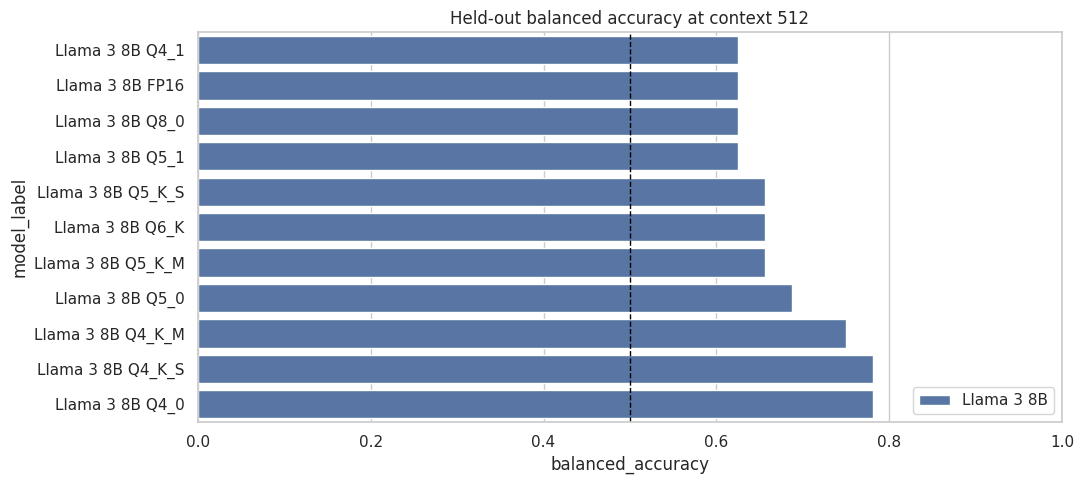

In [10]:
fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(baseline_summary))))
plot_order = baseline_summary.sort_values("balanced_accuracy").model_label
sns.barplot(
    data=baseline_summary,
    x="balanced_accuracy",
    y="model_label",
    hue="family",
    order=plot_order,
    dodge=False,
    ax=ax,
)
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_title(f"Held-out balanced accuracy at context {BASELINE_CONTEXT}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "baseline_accuracy.png", dpi=160, bbox_inches="tight")
plt.show()



## Does accuracy drop for longer text?

One global baseline-context threshold is retained per model. Evaluation rows
are grouped into the four fixed original-token bands used for sampling. The
long-minus-short trend compares 1025–5000 tokens against 150–399 tokens with
a class-stratified bootstrap of
the balanced-accuracy difference:

\[
\Delta = BA_{\mathrm{long}} - BA_{\mathrm{short}}.
\]

A negative interval entirely below zero supports an accuracy drop; an interval
entirely above zero supports an improvement.



,model_id,family,precision,model_label,length_band,n,human_n,ai_n,accuracy,balanced_accuracy
0,base_fp16,Llama 3 8B,FP16,Llama 3 8B FP16,150–399,8.0,4.0,4.0,0.625,0.625
1,base_fp16,Llama 3 8B,FP16,Llama 3 8B FP16,400–699,8.0,4.0,4.0,0.625,0.625
2,base_fp16,Llama 3 8B,FP16,Llama 3 8B FP16,700–1024,8.0,4.0,4.0,0.750,0.750
3,base_fp16,Llama 3 8B,FP16,Llama 3 8B FP16,1025–5000,8.0,4.0,4.0,0.500,0.500
4,base_q4_0,Llama 3 8B,Q4_0,Llama 3 8B Q4_0,150–399,8.0,4.0,4.0,0.750,0.750
5,base_q4_0,Llama 3 8B,Q4_0,Llama 3 8B Q4_0,400–699,8.0,4.0,4.0,0.750,0.750
6,base_q4_0,Llama 3 8B,Q4_0,Llama 3 8B Q4_0,700–1024,8.0,4.0,4.0,0.875,0.875
7,base_q4_0,Llama 3 8B,Q4_0,Llama 3 8B Q4_0,1025–5000,8.0,4.0,4.0,0.750,0.750
8,base_q4_1,Llama 3 8B,Q4_1,Llama 3 8B Q4_1,150–399,8.0,4.0,4.0,0.625,0.625
9,base_q4_1,Llama 3 8B,Q4_1,Llama 3 8B Q4_1,400–699,8.0,4.0,4.0,0.625,0.625


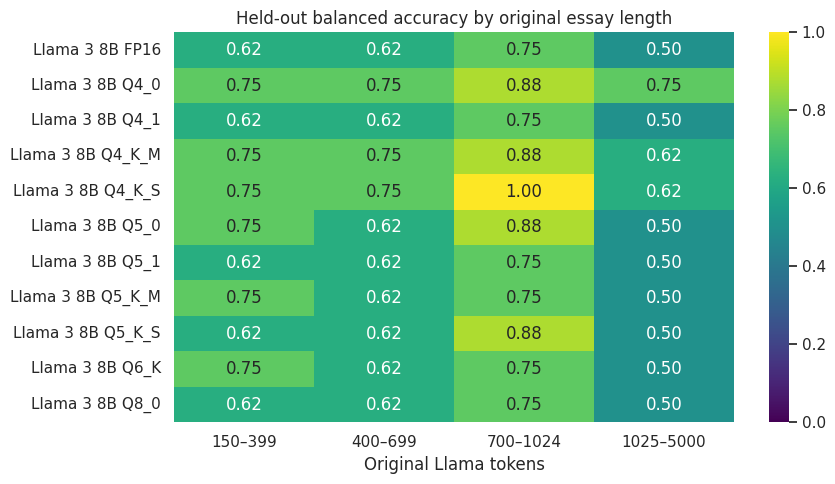

In [11]:
baseline_eval = (
    scores[
        (scores.partition == "evaluation")
        & (scores.context_length == BASELINE_CONTEXT)
    ]
    .dropna(subset=["score", "original_token_count"])
    .merge(baseline_thresholds, on="model_id", how="left")
)
baseline_eval["prediction"] = (
    baseline_eval.score >= baseline_eval.baseline_threshold
).astype(int)
baseline_eval["correct"] = (baseline_eval.prediction == baseline_eval.label).astype(int)

length_labels = [band_label for band_label, _, _ in TOKEN_LENGTH_BANDS]
baseline_eval["length_band"] = pd.Categorical(
    baseline_eval.length_band,
    categories=length_labels,
    ordered=True,
)


def grouped_classification_metrics(group):
    labels = group.label.to_numpy()
    prediction = group.prediction.to_numpy()
    return pd.Series(
        {
            "n": len(group),
            "human_n": int((labels == 0).sum()),
            "ai_n": int((labels == 1).sum()),
            "accuracy": accuracy_score(labels, prediction),
            "balanced_accuracy": (
                balanced_accuracy_score(labels, prediction)
                if len(np.unique(labels)) == 2
                else np.nan
            ),
        }
    )


length_metrics = (
    baseline_eval.groupby(
        ["model_id", "family", "precision", "model_label", "length_band"],
        observed=True,
    )
    [["label", "prediction"]]
    .apply(grouped_classification_metrics)
    .reset_index()
)
display(length_metrics)

length_pivot = length_metrics.pivot(
    index="model_label",
    columns="length_band",
    values="balanced_accuracy",
)
fig, ax = plt.subplots(figsize=(9, max(5, 0.36 * len(length_pivot))))
sns.heatmap(
    length_pivot,
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    cmap="viridis",
    ax=ax,
)
ax.set_title("Held-out balanced accuracy by original essay length")
ax.set_xlabel("Original Llama tokens")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_by_text_length.png", dpi=160, bbox_inches="tight")
plt.show()



In [12]:
def balanced_accuracy_from_predictions(frame):
    if frame.empty or frame.label.nunique() < 2:
        return np.nan
    return balanced_accuracy_score(frame.label, frame.prediction)


def bootstrap_balanced_accuracy_difference(short_frame, long_frame, repeats, seed):
    if (
        short_frame.label.nunique() < 2
        or long_frame.label.nunique() < 2
    ):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    differences = np.empty(repeats, dtype=float)

    short_groups = {
        label: short_frame[short_frame.label == label]
        for label in (0, 1)
    }
    long_groups = {
        label: long_frame[long_frame.label == label]
        for label in (0, 1)
    }

    for repeat in range(repeats):
        short_draw = pd.concat(
            [
                group.iloc[rng.integers(0, len(group), len(group))]
                for group in short_groups.values()
            ]
        )
        long_draw = pd.concat(
            [
                group.iloc[rng.integers(0, len(group), len(group))]
                for group in long_groups.values()
            ]
        )
        differences[repeat] = (
            balanced_accuracy_from_predictions(long_draw)
            - balanced_accuracy_from_predictions(short_draw)
        )

    point = (
        balanced_accuracy_from_predictions(long_frame)
        - balanced_accuracy_from_predictions(short_frame)
    )
    low, high = np.quantile(differences, [0.025, 0.975])
    return float(point), float(low), float(high)


trend_rows = []
short_band = length_labels[0]
long_band = length_labels[-1]
for model_number, (model_id, group) in enumerate(
    baseline_eval.groupby("model_id", sort=False)
):
    short = group[group.length_band == short_band]
    long = group[group.length_band == long_band]
    difference, low, high = bootstrap_balanced_accuracy_difference(
        short,
        long,
        BOOTSTRAP_REPEATS,
        SEED + model_number,
    )
    trend_rows.append(
        {
            "model_id": model_id,
            "family": group.family.iloc[0],
            "precision": group.precision.iloc[0],
            "model_label": group.model_label.iloc[0],
            "short_band": short_band,
            "long_band": long_band,
            "short_max_tokens": (
                int(short.original_token_count.max()) if not short.empty else np.nan
            ),
            "long_min_tokens": (
                int(long.original_token_count.min()) if not long.empty else np.nan
            ),
            "short_n": len(short),
            "long_n": len(long),
            "short_balanced_accuracy": balanced_accuracy_from_predictions(short),
            "long_balanced_accuracy": balanced_accuracy_from_predictions(long),
            "long_minus_short": difference,
            "ci_low": low,
            "ci_high": high,
            "conclusion": (
                "drop supported"
                if high < 0
                else "improvement supported"
                if low > 0
                else "inconclusive"
            ),
        }
    )

length_trends = pd.DataFrame(trend_rows).sort_values("long_minus_short")
display(
    length_trends.style.format(
        {
            "short_balanced_accuracy": "{:.3f}",
            "long_balanced_accuracy": "{:.3f}",
            "long_minus_short": "{:+.3f}",
            "ci_low": "{:+.3f}",
            "ci_high": "{:+.3f}",
        }
    )
)

counts = length_trends.conclusion.value_counts()
print(
    "Length conclusion:",
    f"median long−short ΔBA={length_trends.long_minus_short.median():+.3f};",
    f"{counts.get('drop supported', 0)} drop(s),",
    f"{counts.get('improvement supported', 0)} improvement(s),",
    f"{counts.get('inconclusive', 0)} inconclusive.",
)



,model_id,family,precision,model_label,short_band,long_band,short_max_tokens,long_min_tokens,short_n,long_n,short_balanced_accuracy,long_balanced_accuracy,long_minus_short,ci_low,ci_high,conclusion
6,base_q5_k_m,Llama 3 8B,Q5_K_M,Llama 3 8B Q5_K_M,150–399,1025–5000,399,1052,8,8,0.750,0.500,-0.250,-0.750,+0.250,inconclusive
5,base_q5_0,Llama 3 8B,Q5_0,Llama 3 8B Q5_0,150–399,1025–5000,399,1052,8,8,0.750,0.500,-0.250,-0.750,+0.250,inconclusive
8,base_q6_k,Llama 3 8B,Q6_K,Llama 3 8B Q6_K,150–399,1025–5000,399,1052,8,8,0.750,0.500,-0.250,-0.625,+0.250,inconclusive
0,base_q4_k_s,Llama 3 8B,Q4_K_S,Llama 3 8B Q4_K_S,150–399,1025–5000,399,1052,8,8,0.750,0.625,-0.125,-0.625,+0.375,inconclusive
4,base_q5_k_s,Llama 3 8B,Q5_K_S,Llama 3 8B Q5_K_S,150–399,1025–5000,399,1052,8,8,0.625,0.500,-0.125,-0.625,+0.375,inconclusive
3,base_q4_1,Llama 3 8B,Q4_1,Llama 3 8B Q4_1,150–399,1025–5000,399,1052,8,8,0.625,0.500,-0.125,-0.625,+0.375,inconclusive
7,base_q5_1,Llama 3 8B,Q5_1,Llama 3 8B Q5_1,150–399,1025–5000,399,1052,8,8,0.625,0.500,-0.125,-0.625,+0.375,inconclusive
2,base_q4_k_m,Llama 3 8B,Q4_K_M,Llama 3 8B Q4_K_M,150–399,1025–5000,399,1052,8,8,0.750,0.625,-0.125,-0.500,+0.375,inconclusive
10,base_fp16,Llama 3 8B,FP16,Llama 3 8B FP16,150–399,1025–5000,399,1052,8,8,0.625,0.500,-0.125,-0.625,+0.375,inconclusive
9,base_q8_0,Llama 3 8B,Q8_0,Llama 3 8B Q8_0,150–399,1025–5000,399,1052,8,8,0.625,0.500,-0.125,-0.625,+0.375,inconclusive


Length conclusion: median long−short ΔBA=-0.125; 0 drop(s), 0 improvement(s), 11 inconclusive.


## Effect of changing context length

Two views are important:

- **recalibrated:** each context length gets its own calibration threshold,
  measuring its best calibrated performance;
- **fixed baseline:** every context uses the threshold fitted at
  `BASELINE_CONTEXT`, measuring deployment drift if context length changes
  without recalibration.

The context sweep is intentionally restricted to `context_sweep_model_ids`;
all base quantizations are still compared on the complete corpus at context 512.



,model_label,context_length,threshold_mode,threshold,accuracy,balanced_accuracy,auroc
3,Llama 3 8B Q4_0,128,fixed_baseline,-2.041442,0.84375,0.84375,0.960938
5,Llama 3 8B Q4_0,512,fixed_baseline,-2.041442,0.78125,0.78125,0.894531
7,Llama 3 8B Q4_0,1024,fixed_baseline,-2.041442,0.71875,0.71875,0.890625
2,Llama 3 8B Q4_0,128,recalibrated,-1.790637,0.90625,0.90625,0.960938
4,Llama 3 8B Q4_0,512,recalibrated,-2.041442,0.78125,0.78125,0.894531
6,Llama 3 8B Q4_0,1024,recalibrated,-1.745967,0.84375,0.84375,0.890625


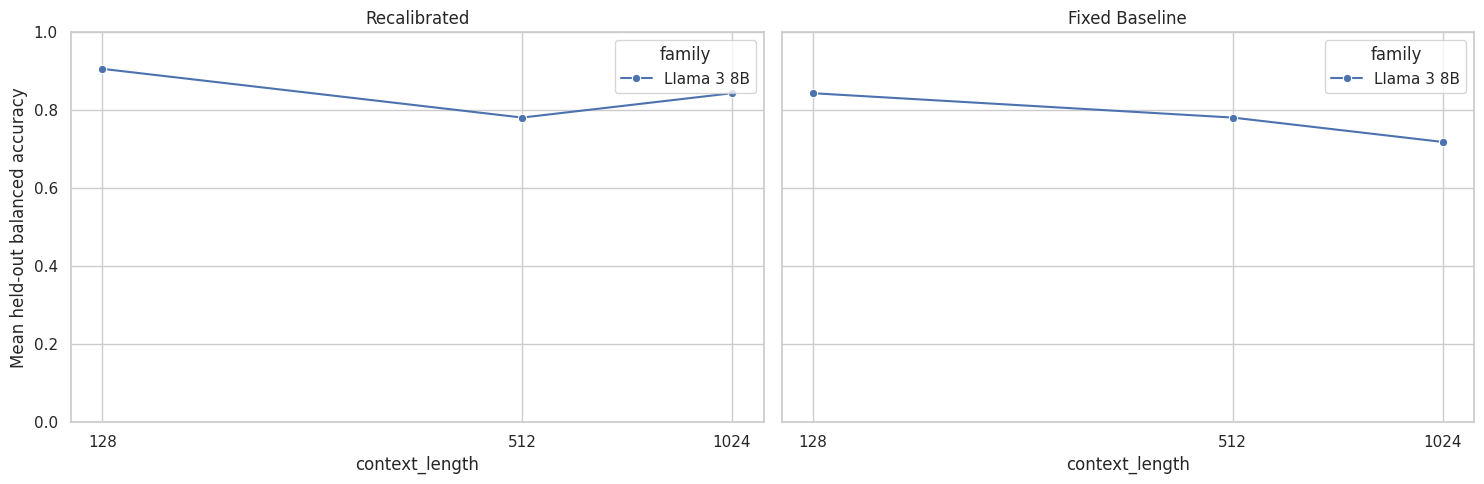

In [13]:
context_metrics = metrics[metrics.model_id.isin(context_sweep_model_ids)].copy()
display(
    context_metrics[
        [
            "model_label",
            "context_length",
            "threshold_mode",
            "threshold",
            "accuracy",
            "balanced_accuracy",
            "auroc",
        ]
    ].sort_values(["model_label", "threshold_mode", "context_length"])
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, mode in zip(axes, ["recalibrated", "fixed_baseline"]):
    family_context = (
        context_metrics[context_metrics.threshold_mode == mode]
        .groupby(["family", "context_length"], as_index=False)
        .agg(
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            sd_balanced_accuracy=("balanced_accuracy", "std"),
        )
    )
    sns.lineplot(
        data=family_context,
        x="context_length",
        y="mean_balanced_accuracy",
        hue="family",
        marker="o",
        ax=ax,
    )
    ax.set_xscale("log", base=2)
    ax.set_xticks(CONTEXT_LENGTHS, labels=CONTEXT_LENGTHS)
    ax.set_ylim(0, 1)
    ax.set_title(mode.replace("_", " ").title())
    ax.set_ylabel("Mean held-out balanced accuracy")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_by_context.png", dpi=160, bbox_inches="tight")
plt.show()



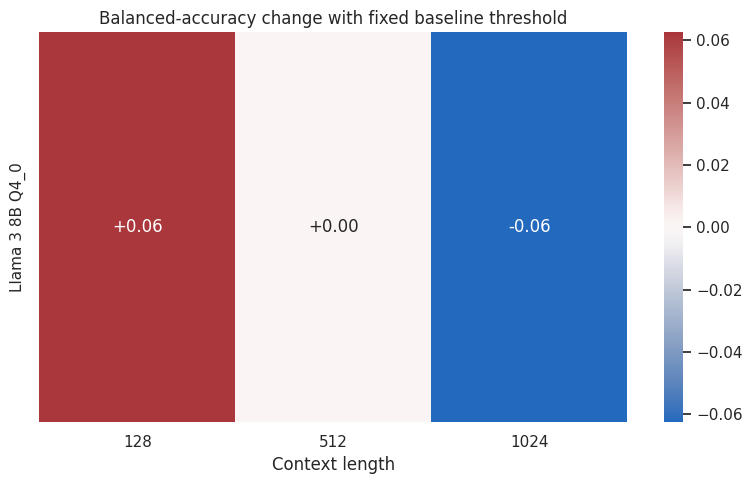

context_length,model_id,model_label,threshold_mode,128,512,baseline_minus_shortest
0,base_q4_0,Llama 3 8B Q4_0,fixed_baseline,0.84375,0.78125,-0.0625
1,base_q4_0,Llama 3 8B Q4_0,recalibrated,0.90625,0.78125,-0.1250


fixed_baseline: mean BA(512)−BA(128) = -0.062; median = -0.062
recalibrated: mean BA(512)−BA(128) = -0.125; median = -0.125


In [14]:
fixed_context = context_metrics[
    context_metrics.threshold_mode == "fixed_baseline"
].copy()
fixed_baseline_values = (
    fixed_context[fixed_context.context_length == BASELINE_CONTEXT][
        ["model_id", "balanced_accuracy"]
    ]
    .rename(columns={"balanced_accuracy": "baseline_balanced_accuracy"})
)
fixed_context = fixed_context.merge(fixed_baseline_values, on="model_id")
fixed_context["delta_from_baseline"] = (
    fixed_context.balanced_accuracy - fixed_context.baseline_balanced_accuracy
)

context_delta_pivot = fixed_context.pivot(
    index="model_label",
    columns="context_length",
    values="delta_from_baseline",
)
fig, ax = plt.subplots(figsize=(8, max(5, 0.36 * len(context_delta_pivot))))
sns.heatmap(
    context_delta_pivot,
    annot=True,
    fmt="+.2f",
    center=0,
    cmap="vlag",
    ax=ax,
)
ax.set_title("Balanced-accuracy change with fixed baseline threshold")
ax.set_xlabel("Context length")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "context_delta_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

shortest = min(CONTEXT_LENGTHS)
context_conclusion = (
    context_metrics[
        context_metrics.context_length.isin([shortest, BASELINE_CONTEXT])
    ]
    .pivot_table(
        index=["model_id", "model_label", "threshold_mode"],
        columns="context_length",
        values="balanced_accuracy",
    )
    .reset_index()
)
context_conclusion["baseline_minus_shortest"] = (
    context_conclusion[BASELINE_CONTEXT] - context_conclusion[shortest]
)
display(context_conclusion.sort_values(["threshold_mode", "baseline_minus_shortest"]))

for mode, group in context_conclusion.groupby("threshold_mode"):
    print(
        f"{mode}: mean BA({BASELINE_CONTEXT})−BA({shortest}) = "
        f"{group.baseline_minus_shortest.mean():+.3f}; "
        f"median = {group.baseline_minus_shortest.median():+.3f}"
    )



## Export reproducible artifacts



In [15]:
thresholds.to_csv(OUTPUT_DIR / "thresholds.csv", index=False)
metrics.to_csv(OUTPUT_DIR / "metrics_by_context.csv", index=False)
baseline_summary.to_csv(OUTPUT_DIR / "baseline_model_summary.csv", index=False)
length_metrics.to_csv(OUTPUT_DIR / "metrics_by_text_length.csv", index=False)
length_trends.to_csv(OUTPUT_DIR / "text_length_trends.csv", index=False)
context_conclusion.to_csv(OUTPUT_DIR / "context_conclusions.csv", index=False)

run_metadata = {
    "seed": SEED,
    "dataset_id": DATASET_ID,
    "dataset_license": DATASET_LICENSE,
    "dataset_revision": DATASET_REVISION,
    "calibration_split": CALIBRATION_SPLIT,
    "evaluation_split": EVALUATION_SPLIT,
    "calibration_per_class": CALIBRATION_PER_CLASS,
    "evaluation_per_class": EVALUATION_PER_CLASS,
    "min_text_tokens": MIN_TEXT_TOKENS,
    "max_text_tokens": MAX_TEXT_TOKENS,
    "token_length_bands": TOKEN_LENGTH_BANDS,
    "context_lengths": CONTEXT_LENGTHS,
    "baseline_context": BASELINE_CONTEXT,
    "context_sweep_model_ids": sorted(context_sweep_model_ids),
    "max_scored_tokens": MAX_SCORED_TOKENS,
    "moment_dtype": np.dtype(MOMENT_DTYPE).name,
    "max_window_overlap": MAX_WINDOW_OVERLAP,
    "models_requested": [model.model_id for model in selected_models],
    "models_completed": sorted(scores.model_id.unique().tolist()),
    "threshold_rule": (
        "score >= threshold; maximize the worse of AI recall and human recall, "
        "then minimize their gap"
    ),
    "length_delta": "BA(1025–5000 tokens) minus BA(150–399 tokens)",
}
(OUTPUT_DIR / "run_metadata.json").write_text(
    json.dumps(run_metadata, indent=2),
    encoding="utf-8",
)

archive = shutil.make_archive(
    str(OUTPUT_DIR),
    "zip",
    root_dir=OUTPUT_DIR,
)
print("Artifacts:", OUTPUT_DIR.resolve())
print("ZIP archive:", archive)
print(sorted(path.name for path in OUTPUT_DIR.iterdir()))



Artifacts: /content/detectllama_results
ZIP archive: /content/detectllama_results.zip
['accuracy_by_context.png', 'accuracy_by_text_length.png', 'all_scores.csv', 'baseline_accuracy.png', 'baseline_model_summary.csv', 'context_conclusions.csv', 'context_delta_heatmap.png', 'metrics_by_context.csv', 'metrics_by_text_length.csv', 'model_failures.csv', 'run_metadata.json', 'samples_polsci__ghostbuster-essay-cleaned_953b44b7_seed20260730_tok150-5000_bands150-399_400-699_700-1024_1025-5000_cal12x2_eval16x2.csv', 'samples_polsci__ghostbuster-essay-cleaned_953b44b7_seed20260730_tok150-5000_bands150-399_400-699_700-1024_1025-5000_cal16x2_eval32x2.csv', 'scores_base_fp16_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv', 'scores_base_q4_0_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c128-512-1024.csv', 'scores_base_q4_0_polsci__ghostbuster-essay-cleaned_953b44b7_n96_t5000_c128-512-1024.csv', 'scores_base_q4_1_polsci__ghostbuster-essay-cleaned_953b44b7_n56_t5000_c512.csv', '

## Interpretation checklist

- Primary metrics use 32 held-out texts (16 human, 16 AI); accuracy therefore
  changes in 3.125-point steps and each class recall in 6.25-point steps.
- Every sampled text has 150–5000 exact Llama tokens and is scored up to the
  configured 5000-token application limit.
- Use `baseline_model_summary.csv` for the primary per-quantization comparison.
- Use `text_length_trends.csv` to answer whether longer text lowers accuracy.
  Treat `inconclusive` as insufficient evidence, not as proof of no effect.
- Use `metrics_by_context.csv` to compare recalibrated and fixed-threshold
  context changes.
- Inspect class-specific recall and confusion counts, not accuracy alone.
- The primary threshold maximizes the weaker of AI recall and human recall;
  inspect `class_recall_gap` to verify that deployment remains balanced.
- Long-text exact scoring is expensive. Resume from per-model checkpoints after
  interruptions instead of restarting the complete sweep.
- These labels combine heterogeneous human and AI sources. Report results as
  performance on this dataset revision, not as a universal detector benchmark.
